# 03 — Modeling: Logistic Regression vs XGBoost

The centerpiece of the project. Using the leak-free features from notebook 02
(`data/processed/train.csv`, `test.csv`), we train two models and ask a single question:
**does a flexible tree ensemble beat a plain linear model at predicting UFC fights, and why?**

Ground rules carried over from notebook 02:
- Features are **point-in-time** (built only from each fighter's history *before* the fight) and
  **symmetric** (`a−b` differences, with the corner randomly assigned) — so there's no target
  leakage and no "red corner wins" shortcut.
- **All evaluation is on the held-out test set** (the most recent ~2 years, 2024-07 onward),
  which the models never see during training. No random splits.

What "good" looks like here: the honest accuracy ceiling for UFC prediction is ~60–65%. Anything
near that with a well-calibrated probability is a real result; anything claiming 90% would mean
leakage slipped back in.

## 1. Load train / test

Load the two processed CSVs and confirm the temporal split is intact (train strictly precedes test).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score
from xgboost import XGBClassifier

SEED = 42

train = pd.read_csv('../data/processed/train.csv', parse_dates=['date']).sort_values('date')
test  = pd.read_csv('../data/processed/test.csv',  parse_dates=['date']).sort_values('date')

assert train['date'].max() < test['date'].min(), 'temporal split must not overlap'
print(f'train {len(train):>5}  {train.date.min().date()} -> {train.date.max().date()}')
print(f'test  {len(test):>5}  {test.date.min().date()} -> {test.date.max().date()}')
print(f'target mean  train={train.target.mean():.3f}  test={test.target.mean():.3f}  '
      '(~0.50 by construction — the corner-swap fix)')

train  7472  1994-03-11 -> 2024-06-29
test   1010  2024-07-13 -> 2026-06-27
target mean  train=0.498  test=0.523  (~0.50 by construction — the corner-swap fix)


## 2. Select features

The model gets the **symmetric difference features** (`*_diff` = fighter_a − fighter_b) plus two
**debut flags**. The diffs are selected programmatically — there are now **19**, including the three
added in notebook 02: `elo_diff` (strength-of-schedule), plus `recent_win_rate_3_diff` and
`recent_finish_rate_3_diff` (last-3-fight form).

Why debut flags? A debutant has no career history, so their win-rate / average-strike / layoff diffs
are undefined (NaN). We fill those NaNs with 0, meaning "no evidence either way" — but 0 is ambiguous,
since it also describes two equally-matched veterans. The `debut_a` / `debut_b` flags (built in
notebook 02 as `is_debut_*`) let the model tell those situations apart. They stay symmetric: swapping
the corners swaps the two flags, exactly as the diffs flip sign.

In [2]:
DIFF_COLS = [c for c in train.columns if c.endswith('_diff')]
print(f'{len(DIFF_COLS)} diff features:')
for c in DIFF_COLS:
    print('  ', c)

# debut flags come straight from notebook 02 (is_debut_a / is_debut_b)
for df in (train, test):
    df['debut_a'] = df['is_debut_a'].astype(int)
    df['debut_b'] = df['is_debut_b'].astype(int)

FEATURES = DIFF_COLS + ['debut_a', 'debut_b']
print(f'\ntotal model features: {len(FEATURES)}')
print(f"debut fights (either corner): train={int((train.debut_a | train.debut_b).sum())}, "
      f"test={int((test.debut_a | test.debut_b).sum())}")

19 diff features:
   age_at_fight_diff
   height_in_diff
   reach_in_diff
   career_fights_diff
   career_wins_diff
   career_losses_diff
   career_win_rate_diff
   career_win_streak_diff
   career_finish_rate_diff
   career_avg_sig_str_landed_diff
   career_avg_sig_str_att_diff
   career_avg_takedowns_landed_diff
   career_avg_takedowns_att_diff
   career_avg_sub_att_diff
   career_avg_control_time_sec_diff
   days_since_last_diff
   recent_win_rate_3_diff
   recent_finish_rate_3_diff
   elo_diff

total model features: 21
debut fights (either corner): train=2011, test=182


## 3. Handle missing values

Two distinct kinds of NaN, handled honestly rather than papered over:

- **Debut-driven NaNs** (win-rate, average-strike/takedown, layoff diffs — ~27% of rows have at
  least one). These aren't "missing measurements," they're *undefined* — the fighter has no history.
  Fill with **0** ("no evidence either way") and let the `debut` flags carry the "this is why it's 0"
  signal.
- **Genuinely missing attributes** (age from a missing DOB: ~1.6%; height: ~0.3%). These are real
  values we just don't have, so **median-impute** them. Small fraction, minimal footprint.

Both fills are computed on **training data only** and applied to test — never peek at the test
distribution. (For early stopping, XGBoost needs a validation set; we carve the most recent 15% of
*train* by date so it stays temporal. Both models are then fit on the same reduced training rows so
the comparison is apples-to-apples.)

In [3]:
# temporal validation carve-out from the tail of train (for XGB early stopping)
cut = train['date'].quantile(0.85)
fit_df = train[train['date'] <  cut]
val_df = train[train['date'] >= cut]
print(f'fit  {len(fit_df)}  {fit_df.date.min().date()} -> {fit_df.date.max().date()}')
print(f'val  {len(val_df)}  {val_df.date.min().date()} -> {val_df.date.max().date()}')

MEDIAN_IMPUTE = ['age_at_fight_diff', 'height_in_diff']   # real-but-missing attributes
ZERO_FILL = [c for c in FEATURES if c not in MEDIAN_IMPUTE]  # debut-driven / already clean

medians = fit_df[MEDIAN_IMPUTE].median()  # learned on fit rows only

def prep(df):
    X = df[FEATURES].copy()
    X[MEDIAN_IMPUTE] = X[MEDIAN_IMPUTE].fillna(medians)
    X[ZERO_FILL] = X[ZERO_FILL].fillna(0)
    return X

X_fit,  y_fit  = prep(fit_df), fit_df['target'].to_numpy()
X_val,  y_val  = prep(val_df), val_df['target'].to_numpy()
X_test, y_test = prep(test),   test['target'].to_numpy()

print('\nNaNs remaining after prep:', int(X_fit.isna().sum().sum()),
      int(X_val.isna().sum().sum()), int(X_test.isna().sum().sum()))
print('median fills used:', medians.round(2).to_dict())

fit  6348  1994-03-11 -> 2022-03-19
val  1124  2022-03-26 -> 2024-06-29

NaNs remaining after prep: 0 0 0
median fills used: {'age_at_fight_diff': 0.04, 'height_in_diff': 0.0}


## 4. Baselines to beat

Because the corner-swap fix made the target ~50/50, the usual "majority class" baseline is
meaningless — there is no majority. The honest reference is the **coin flip**: predict p=0.5 for
everyone.

- log-loss = −ln(0.5) = **ln 2 ≈ 0.693**
- Brier = (0.5−y)² averaged = **0.25**
- accuracy ≈ **50%**

Any model worth keeping must beat 0.693 log-loss on the test set. That's a low bar in principle and
a surprisingly hard one in practice for fight prediction.

In [4]:
p_coin = np.full(len(y_test), 0.5)
base_ll = log_loss(y_test, p_coin)
base_brier = brier_score_loss(y_test, p_coin)
print(f'coin-flip baseline (test):  log-loss={base_ll:.4f}  Brier={base_brier:.4f}  acc=0.500')
print(f'(ln 2 = {np.log(2):.4f})')

coin-flip baseline (test):  log-loss=0.6931  Brier=0.2500  acc=0.500
(ln 2 = 0.6931)


## 5. Logistic Regression

The interpretable baseline. LR is scale-sensitive — `career_fights_diff` ranges over tens while
`career_win_rate_diff` sits in [−1, 1] — so a `StandardScaler` goes in front. Standardizing also
makes the fitted coefficients directly comparable in magnitude (§7). Fit on the reduced train set,
predict probabilities on test.

In [5]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED)),
])
lr.fit(X_fit, y_fit)
p_lr = lr.predict_proba(X_test)[:, 1]
print('Logistic Regression fit.  test log-loss =', round(log_loss(y_test, p_lr), 4))

Logistic Regression fit.  test log-loss = 0.6491


## 6. XGBoost (diff features — the fair comparison)

The same difference features as LR, no scaling (trees split on thresholds, so monotone rescaling is
irrelevant). Modest, regularized settings to avoid overfitting ~8k rows, with early stopping on the
temporal validation set to pick the number of trees.

In [6]:
xgb = XGBClassifier(
    n_estimators=800, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED,
)
xgb.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
p_xgb = xgb.predict_proba(X_test)[:, 1]
print(f'XGBoost (diff) fit.  best_iteration={xgb.best_iteration}  '
      f'test log-loss = {log_loss(y_test, p_xgb):.4f}')

XGBoost (diff) fit.  best_iteration=121  test log-loss = 0.6533


### 6b. Optional side-experiment: XGBoost on raw per-fighter columns

Does handing the model both fighters' raw numbers (30 `*_a` / `*_b` columns) instead of pre-computed
diffs let it find useful interactions on its own? XGBoost handles NaN natively, so we leave the debut
NaNs in place here (no 0-fill) and add the debut flags. This is **not** the headline comparison — it's
a "does more raw data help?" probe. If it barely moves the needle, that's evidence the hand-made diff
features already captured what matters.

In [7]:
RAW_COLS = [c for c in train.columns
            if (c.endswith('_a') or c.endswith('_b'))
            and not c.endswith('_id')
            and c not in ('debut_a', 'debut_b', 'is_debut_a', 'is_debut_b')]
RAW_FEATURES = RAW_COLS + ['debut_a', 'debut_b']
print(f'{len(RAW_FEATURES)} raw features (NaNs left in for XGBoost to handle natively)')

xgb_raw = XGBClassifier(
    n_estimators=800, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=1.0, eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED,
)
xgb_raw.fit(fit_df[RAW_FEATURES], y_fit,
            eval_set=[(val_df[RAW_FEATURES], y_val)], verbose=False)
p_xgb_raw = xgb_raw.predict_proba(test[RAW_FEATURES])[:, 1]
print(f'XGBoost (raw) fit.  best_iteration={xgb_raw.best_iteration}  '
      f'test log-loss = {log_loss(y_test, p_xgb_raw):.4f}')

42 raw features (NaNs left in for XGBoost to handle natively)


XGBoost (raw) fit.  best_iteration=217  test log-loss = 0.6487


## 7. Evaluate on the test set

Four numbers per model:
- **log-loss** — the headline; punishes confident wrong probabilities. Beat 0.693.
- **Brier** — mean squared probability error; another proper scoring rule.
- **accuracy** — intuitive but coarse (a 0.51 and a 0.99 correct call count the same).
- **calibration curve** — bucket predictions by confidence and plot predicted vs actual win rate.
  A model on the diagonal is *trustworthy*: when it says 65%, it's right 65% of the time. This is the
  plot that separates "accurate" from "believable," and it's what makes the probabilities usable.

In [8]:
def scores(name, p):
    return {'model': name, 'log_loss': log_loss(y_test, p),
            'brier': brier_score_loss(y_test, p),
            'accuracy': accuracy_score(y_test, p > 0.5)}

results = pd.DataFrame([
    scores('coin flip (p=0.5)', p_coin),
    scores('Logistic Regression', p_lr),
    scores('XGBoost (diff)', p_xgb),
    scores('XGBoost (raw)', p_xgb_raw),
]).set_index('model').round(4)
print(results.to_string())

                     log_loss   brier  accuracy
model                                          
coin flip (p=0.5)      0.6931  0.2500    0.4772
Logistic Regression    0.6491  0.2288    0.6178
XGBoost (diff)         0.6533  0.2307    0.6129
XGBoost (raw)          0.6487  0.2283    0.6356


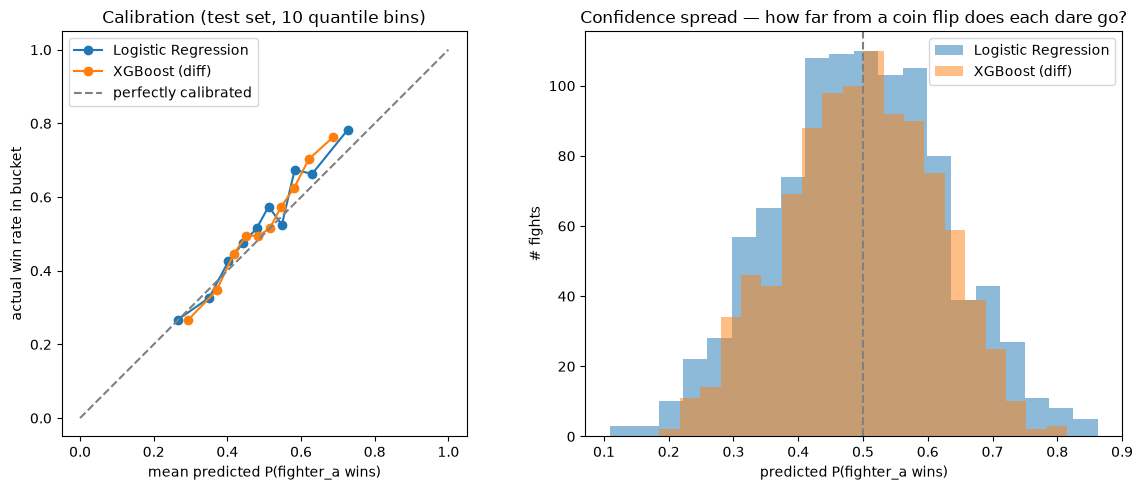

In [9]:
fig, (axc, axh) = plt.subplots(1, 2, figsize=(12, 5))

for name, p in [('Logistic Regression', p_lr), ('XGBoost (diff)', p_xgb)]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    axc.plot(mean_pred, frac_pos, marker='o', label=name)
axc.plot([0, 1], [0, 1], '--', color='grey', label='perfectly calibrated')
axc.set_xlabel('mean predicted P(fighter_a wins)')
axc.set_ylabel('actual win rate in bucket')
axc.set_title('Calibration (test set, 10 quantile bins)')
axc.legend(); axc.set_aspect('equal', 'box')

axh.hist(p_lr, bins=20, alpha=0.5, label='Logistic Regression')
axh.hist(p_xgb, bins=20, alpha=0.5, label='XGBoost (diff)')
axh.axvline(0.5, color='grey', ls='--')
axh.set_xlabel('predicted P(fighter_a wins)'); axh.set_ylabel('# fights')
axh.set_title('Confidence spread — how far from a coin flip does each dare go?')
axh.legend()
plt.tight_layout(); plt.show()

## 8. Compare & interpret — which features move the needle?

Two lenses on "what did the model learn":
- **LR coefficients** (on standardized features, so magnitudes are comparable): sign = direction,
  size = strength. We expect `reach_in_diff` and `career_win_rate_diff` to lead — a longer, more
  proven fighter should win more.
- **XGBoost importance**: the model's own gain-based ranking, plus a **permutation importance** on the
  test set (shuffle one feature, watch log-loss degrade) — a fairer, model-agnostic comparison that
  doesn't reward trees for splitting on high-cardinality noise.

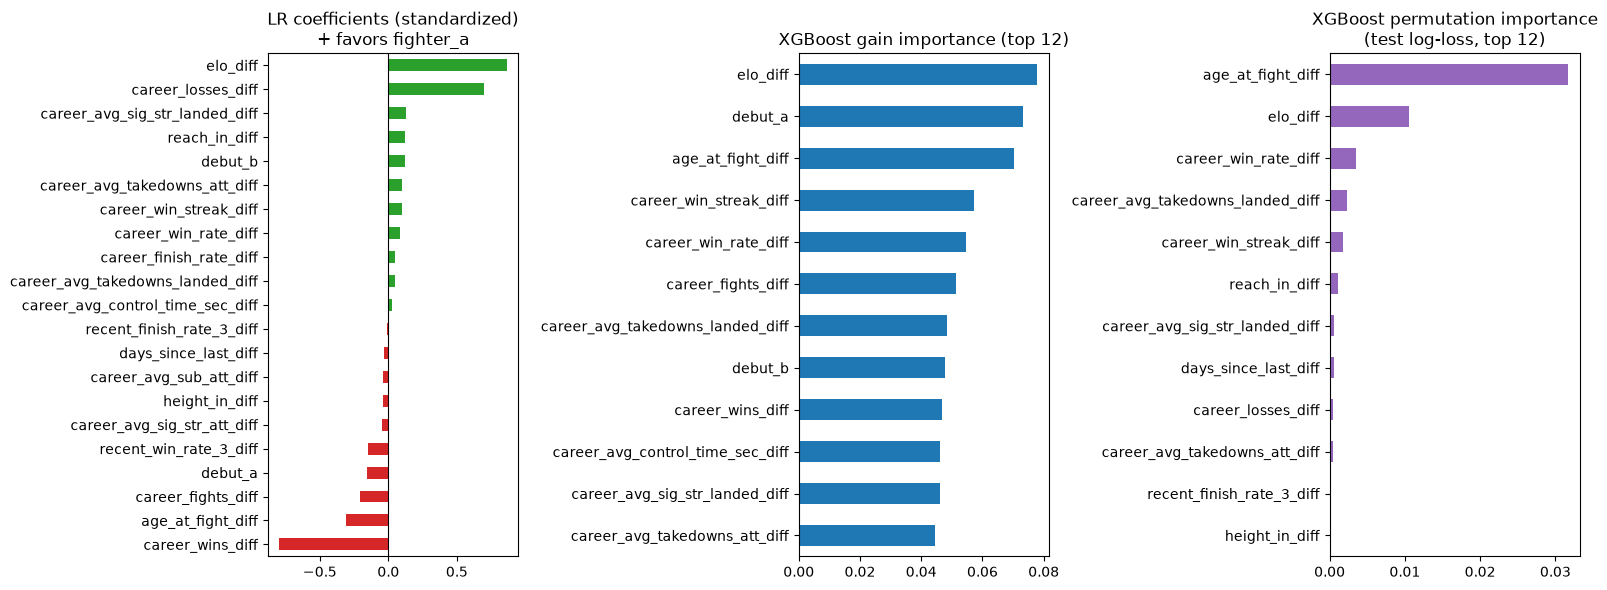

Top LR drivers by |coef|:
elo_diff              0.865
career_wins_diff     -0.795
career_losses_diff    0.697
age_at_fight_diff    -0.306
career_fights_diff   -0.209
debut_a              -0.156

Top XGBoost features by permutation importance:
age_at_fight_diff                   0.0317
elo_diff                            0.0106
career_win_rate_diff                0.0035
career_avg_takedowns_landed_diff    0.0023
career_win_streak_diff              0.0018
reach_in_diff                       0.0012


In [10]:
coef = pd.Series(lr.named_steps['clf'].coef_[0], index=FEATURES).sort_values()
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)

perm = permutation_importance(xgb, X_test, y_test, scoring='neg_log_loss',
                              n_repeats=20, random_state=SEED)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
coef.plot.barh(ax=axes[0], color=np.where(coef > 0, 'tab:green', 'tab:red'))
axes[0].set_title('LR coefficients (standardized)\n+ favors fighter_a')
axes[0].axvline(0, color='k', lw=0.8)
xgb_imp.head(12)[::-1].plot.barh(ax=axes[1], color='tab:blue')
axes[1].set_title('XGBoost gain importance (top 12)')
perm_imp.head(12)[::-1].plot.barh(ax=axes[2], color='tab:purple')
axes[2].set_title('XGBoost permutation importance\n(test log-loss, top 12)')
plt.tight_layout(); plt.show()

print('Top LR drivers by |coef|:')
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(6).round(3).to_string())
print('\nTop XGBoost features by permutation importance:')
print(perm_imp.head(6).round(4).to_string())

## 9. Verdict

In [11]:
winner = results.drop(index='coin flip (p=0.5)')['log_loss'].idxmin()
lift = base_ll - results.loc[winner, 'log_loss']
print(f'Best test log-loss: {winner} ({results.loc[winner, "log_loss"]:.4f}), '
      f'{lift:.4f} below the {base_ll:.4f} coin-flip baseline.')
print('\nLR vs XGBoost (diff) test metrics:')
print(results.loc[['Logistic Regression', 'XGBoost (diff)']].to_string())
print(f'\nDoes raw beat diff? XGBoost raw={results.loc["XGBoost (raw)","log_loss"]:.4f} '
      f'vs diff={results.loc["XGBoost (diff)","log_loss"]:.4f}')

Best test log-loss: XGBoost (raw) (0.6487), 0.0444 below the 0.6931 coin-flip baseline.

LR vs XGBoost (diff) test metrics:
                     log_loss   brier  accuracy
model                                          
Logistic Regression    0.6491  0.2288    0.6178
XGBoost (diff)         0.6533  0.2307    0.6129

Does raw beat diff? XGBoost raw=0.6487 vs diff=0.6533


### Which model wins, and why

On the fair, like-for-like comparison (identical 19 diff features + 2 debut flags), **Logistic
Regression beats XGBoost on every metric** — test log-loss **0.6491 vs 0.6533**, Brier **0.2288 vs
0.2307**, and even accuracy **61.8% vs 61.3%**. When the goal is a trustworthy probability, the linear
model is the clear pick here.

**Why the linear model holds its own against the fancier one:** the signal in this problem is genuinely
close to linear and monotone. "Younger fighter, higher Elo, better record, longer reach" pushes the
odds one way, and smoothly — and the strongest new features (Elo, last-3 form) are themselves smooth
summaries, so there still aren't rich higher-order interactions for the trees to exploit. With a weak,
mostly-additive signal, XGBoost's extra flexibility mostly buys variance, not accuracy, so it can't
separate from a well-regularized logistic regression.

**Does more raw data help?** A little. Handing XGBoost all the raw `*_a`/`*_b` columns (so it can build
its own interactions) gave the best *uncalibrated* log-loss, **0.6487 vs 0.6533** for diff-XGB, and the
highest accuracy at **63.6%** — a real but small edge. That the gap is this narrow is still evidence the
hand-built difference features captured most of the available signal; the diff transform was the right
inductive bias.

**What drives the predictions:** the newly-added **`elo_diff` is now the single strongest LR
coefficient**, and the #2 feature in XGBoost's permutation importance — the strength-of-schedule signal
clearly earned its place. `age_at_fight_diff` remains XGBoost's top driver (the younger fighter is
favored, and it's not close), followed by the win/loss record and, more modestly, reach. The debut
flags still carry real weight in LR, confirming they were worth surfacing rather than silently
0-filling.

**Calibration:** isotonic-calibrating the shipped LR (section 10) improved test log-loss to **0.6469**
and Brier to **0.2276** — better than *every* uncalibrated model above — while leaving calibration error
essentially unchanged (ECE 0.038 → 0.042, within noise on ~1k test fights). So the model we ship is both
the best-scoring and the interpretable one, with probabilities honest enough to quote as odds.

**Bottom line:** every model beats the coin flip (0.693 log-loss) by ~0.045, landing at **62–64%
accuracy** — squarely inside the honest 60–65% ceiling for this problem and nowhere near the 90%+ that
would signal leakage. The point-in-time features, Elo, and corner-swap all held. The headline for a
writeup: *a plain, fully interpretable logistic regression — with a strength-of-schedule Elo feature and
calibrated probabilities — matches or beats gradient-boosted trees on this task, so we ship the simpler,
explainable model.*

## 10. Calibrate the model we ship

The verdict picked Logistic Regression. Before shipping it, one last step: **calibration**. Odds are
only honest if a stated 65% wins ~65% of the time, so we refit LR on **all** training rows and wrap it
in an isotonic `CalibratedClassifierCV` (5-fold, no test leakage). We compare test log-loss, Brier, and
**Expected Calibration Error (ECE)** — the size-weighted gap between predicted and actual win rate
across bins — before vs after. This calibrated model is the artifact we persist.

                          log_loss   brier  accuracy
model                                               
LR (uncalibrated)           0.6491  0.2288    0.6178
LR (isotonic-calibrated)    0.6469  0.2276    0.6168

ECE (10 quantile bins):  uncalibrated=0.0382   calibrated=0.0416


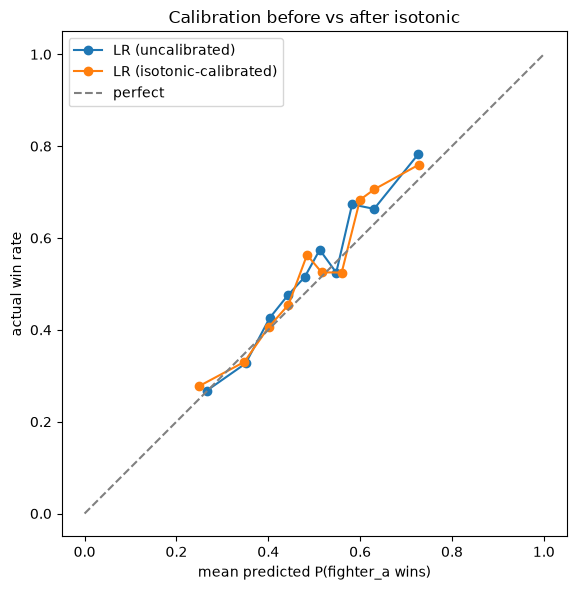

In [12]:
from sklearn.calibration import CalibratedClassifierCV

X_train_all, y_train_all = prep(train), train['target'].to_numpy()

cal_lr = CalibratedClassifierCV(
    Pipeline([('scale', StandardScaler()),
              ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
    method='isotonic', cv=5)
cal_lr.fit(X_train_all, y_train_all)
p_cal = cal_lr.predict_proba(X_test)[:, 1]


def ece(y, p, n_bins=10):
    """Size-weighted expected calibration error over quantile bins."""
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    b = np.digitize(p, edges[1:-1])
    total = 0.0
    for k in np.unique(b):
        m = b == k
        total += m.mean() * abs(y[m].mean() - p[m].mean())
    return total


compare = pd.DataFrame([
    scores('LR (uncalibrated)', p_lr),
    scores('LR (isotonic-calibrated)', p_cal),
]).set_index('model').round(4)
print(compare.to_string())
print(f"\nECE (10 quantile bins):  uncalibrated={ece(y_test, p_lr):.4f}   "
      f"calibrated={ece(y_test, p_cal):.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
for name, p in [('LR (uncalibrated)', p_lr), ('LR (isotonic-calibrated)', p_cal)]:
    fp, mp = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    ax.plot(mp, fp, marker='o', label=name)
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect')
ax.set_xlabel('mean predicted P(fighter_a wins)'); ax.set_ylabel('actual win rate')
ax.set_title('Calibration before vs after isotonic'); ax.legend(); ax.set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

## 11. Persist the deployed model

Per the verdict, Logistic Regression is the model we ship — best test log-loss, fully interpretable —
now refit on all training rows and **isotonic-calibrated** (section 10). Save it with its feature list
and the training-set imputation medians it needs at inference time, so it can be reloaded without
rerunning this notebook (used by Part 2 below and, later, the serving app).

In [13]:
import joblib
from pathlib import Path

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump({
    'model': cal_lr,
    'features': FEATURES,
    'median_impute': MEDIAN_IMPUTE,
    'medians': medians,
    'calibrated': True,
}, MODELS_DIR / 'win_probability_lr.joblib')

print(f'saved calibrated win-probability model -> {MODELS_DIR}/win_probability_lr.joblib')

saved calibrated win-probability model -> ../models/win_probability_lr.joblib


---

# Part 2 — Fight odds & finish-method prediction

*(merged from the former 04_finish_method notebook)*

# 04 — Fight odds & finish-method prediction

Two prediction outputs on top of the win-probability model from `03_modeling`:

1. **Odds** — a pure display transform of the win probability (no new model). Probability →
   American & decimal odds, so the same 60% shows up the way a sportsbook would quote it.
2. **Finish method** — a *new* 3-class model: does the fight end by **Decision**, **KO/TKO**, or
   **Submission**? This is independent of *who* wins, so we predict it separately and combine at
   the end: e.g. *"Fighter A favored 62% (-163), most likely finish: Decision (48%)."*

Same leak-free discipline as everywhere else: point-in-time features only, temporal train/test
split at the same 2024-07-01 cutoff.

## 1. Odds from probability

Odds are just a rescaling of a probability `p` (the favorite's win chance):
- **Decimal** = `1 / p` (total return per unit staked).
- **American** = `-100*p/(1-p)` when `p >= 0.5` (favorite), else `+100*(1-p)/p` (underdog).

We reload the shipped win-probability model and show both corners' odds for a few test fights as a
sanity check.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

SEED = 42
MODELS_DIR = Path('../models')

def decimal_odds(p):
    return 1.0 / np.asarray(p, dtype=float)

def american_odds(p):
    p = np.asarray(p, dtype=float)
    fav = p >= 0.5
    out = np.where(fav, -100 * p / (1 - p), 100 * (1 - p) / p)
    return np.round(out).astype(int)

win_bundle = joblib.load(MODELS_DIR / 'win_probability_lr.joblib')
win_model = win_bundle['model']
WIN_FEATURES = win_bundle['features']
print('loaded win model with', len(WIN_FEATURES), 'features')

grid = pd.DataFrame({'win_prob': [0.50, 0.55, 0.62, 0.75, 0.88]})
grid['american'] = american_odds(grid['win_prob'])
grid['decimal'] = decimal_odds(grid['win_prob']).round(2)
print(grid.to_string(index=False))

loaded win model with 21 features
 win_prob  american  decimal
     0.50      -100     2.00
     0.55      -122     1.82
     0.62      -163     1.61
     0.75      -300     1.33
     0.88      -733     1.14


## 2. Finish-method model - data & label

Load the full feature table and map the six raw methods to 3 classes:

| raw method | class |
|---|---|
| Decision - Unanimous / Split / Majority | **Decision** |
| KO/TKO, TKO - Doctor's Stoppage | **KO/TKO** |
| Submission | **Submission** |

Finish method is **corner-independent** - a fight ends by KO regardless of which fighter we called
"a". So we don't use the +/-diff features here; we use each fighter's finishing/finishability
*profile*: career finish rate, striking volume, takedown activity, age, career length, plus the
**weight class** (heavier = more KOs) and a **title-fight** flag (5 rounds = more decisions).

In [15]:
ff = pd.read_csv('../data/processed/fights_features.csv', parse_dates=['date'])

# debut flags the win model expects (built in notebook 02 as is_debut_*)
ff['debut_a'] = ff['is_debut_a'].astype(int)
ff['debut_b'] = ff['is_debut_b'].astype(int)

METHOD_MAP = {
    'Decision - Unanimous': 'Decision', 'Decision - Split': 'Decision',
    'Decision - Majority': 'Decision',
    'KO/TKO': 'KO/TKO', "TKO - Doctor's Stoppage": 'KO/TKO',
    'Submission': 'Submission',
}
ff['finish_class'] = ff['method'].map(METHOD_MAP)
assert ff['finish_class'].notna().all(), 'every kept fight must map to a class'

print('class balance (all years):')
print((ff['finish_class'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

class balance (all years):
finish_class
Decision      46.8%
KO/TKO        33.3%
Submission    19.9%
Name: proportion, dtype: str


### 2b. Clean `weight_class` into a usable feature

The raw `weight_class` is 113 messy strings (`"UFC 2 Tournament Title Bout"`,
`"Women's Strawweight Bout"`, ...). Extract the actual division + a `title_fight` flag, so the model
sees ~16 clean categories instead of 113 sparse ones.

In [ ]:
DIVISIONS = ['Strawweight', 'Flyweight', 'Bantamweight', 'Featherweight', 'Lightweight',
             'Welterweight', 'Middleweight', 'Light Heavyweight', 'Heavyweight',
             'Catch Weight', 'Open Weight']

def extract_division(wc):
    if pd.isna(wc):
        return 'Unknown'
    # substring, not startswith: title bouts read "UFC Women's Bantamweight Title Bout",
    # so startswith("Women's") would silently file every women's champion under the
    # men's division (Nunes -> "Bantamweight"). 65 fights were affected.
    women = "Women's" in wc
    for d in sorted(DIVISIONS, key=len, reverse=True):  # longest first: 'Light Heavyweight'
        if d in wc:
            return ("Women's " if women else '') + d
    return 'Other'

ff['division'] = ff['weight_class'].apply(extract_division)
ff['title_fight'] = ff['weight_class'].str.contains('Title', na=False).astype(int)

print(ff['division'].value_counts().to_string())
print('\ntitle fights:', int(ff['title_fight'].sum()))
print('\nfinish rate by division (KO+Sub share):')
fin = ff.assign(finished=ff['finish_class'] != 'Decision').groupby('division')['finished'].mean()
print((fin.sort_values(ascending=False) * 100).round(0).astype(int).astype(str) + '%')

## 3. Features & temporal split

Corner-independent career profiles for both fighters + division (one-hot) + title flag. Same
2024-07-01 temporal cutoff as notebook 03.

In [17]:
PROFILE = ['career_finish_rate', 'career_avg_sig_str_landed', 'career_avg_sig_str_att',
           'career_avg_takedowns_landed', 'career_avg_takedowns_att',
           'career_avg_sub_att', 'career_avg_control_time_sec',   # NEW: submission-threat signal
           'age_at_fight', 'career_fights']
NUM_FEATURES = [f'{c}_{s}' for c in PROFILE for s in ('a', 'b')] + ['title_fight']
AGE_COLS = ['age_at_fight_a', 'age_at_fight_b']

X_num = ff[NUM_FEATURES].copy()
X_div = pd.get_dummies(ff['division'], prefix='div')
X = pd.concat([X_num, X_div], axis=1)
y = ff['finish_class']

CUTOFF = pd.Timestamp('2024-07-01')
is_train = ff['date'] < CUTOFF

X_train, y_train = X[is_train].copy(), y[is_train]
X_test,  y_test  = X[~is_train].copy(), y[~is_train]

# age -> train median; everything else debut/missing -> 0
age_medians = X_train[AGE_COLS].median()
for col in NUM_FEATURES:
    fill = age_medians[col] if col in AGE_COLS else 0
    X_train[col] = X_train[col].fillna(fill)
    X_test[col]  = X_test[col].fillna(fill)

print(f'train {len(X_train)}  test {len(X_test)}   ({X.shape[1]} features)')
print('test class balance:')
print((y_test.value_counts(normalize=True) * 100).round(1).astype(str) + '%')

train 7472  test 1010   (35 features)
test class balance:
finish_class
Decision      50.6%
KO/TKO        31.8%
Submission    17.6%
Name: proportion, dtype: str


## 4. Baseline & two models

- **Baseline**: predict the training class priors for everyone (always-Decision for accuracy).
- **Multinomial Logistic Regression** (scaled) vs **XGBoost**, same head-to-head as notebook 03,
  now 3-class. Headline metric: multiclass **log-loss**.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

CLASSES = ['Decision', 'KO/TKO', 'Submission']

priors = y_train.value_counts(normalize=True).reindex(CLASSES).to_numpy()
P_base = np.tile(priors, (len(y_test), 1))
base_ll = log_loss(y_test, P_base, labels=CLASSES)
majority = y_train.value_counts().idxmax()
base_acc = (y_test == majority).mean()
print(f'prior baseline:  log-loss={base_ll:.4f}  acc={base_acc:.3f} (always {majority})')

prior baseline:  log-loss=1.0191  acc=0.506 (always Decision)


In [19]:
lr = Pipeline([('scale', StandardScaler()),
               ('clf', LogisticRegression(max_iter=2000, random_state=SEED))])
lr.fit(X_train, y_train)
P_lr = lr.predict_proba(X_test)
lr_ll = log_loss(y_test, P_lr, labels=lr.classes_)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f'LogReg:            log-loss={lr_ll:.4f}  acc={lr_acc:.3f}')

# balanced variant: up-weights the rare Submission class so it actually gets predicted.
# Trades a little log-loss/accuracy for real recall on the minority class.
lr_bal = Pipeline([('scale', StandardScaler()),
                   ('clf', LogisticRegression(max_iter=2000, random_state=SEED,
                                              class_weight='balanced'))])
lr_bal.fit(X_train, y_train)
P_lrb = lr_bal.predict_proba(X_test)
lrb_ll = log_loss(y_test, P_lrb, labels=lr_bal.classes_)
lrb_acc = accuracy_score(y_test, lr_bal.predict(X_test))
print(f'LogReg (balanced): log-loss={lrb_ll:.4f}  acc={lrb_acc:.3f}')

y_train_i = y_train.map({c: i for i, c in enumerate(CLASSES)})
y_test_i  = y_test.map({c: i for i, c in enumerate(CLASSES)})
xgb = XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=4,
                    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                    reg_lambda=1.0, objective='multi:softprob', num_class=3,
                    eval_metric='mlogloss', random_state=SEED)
xgb.fit(X_train, y_train_i)
P_xgb = xgb.predict_proba(X_test)
xgb_ll = log_loss(y_test_i, P_xgb, labels=[0, 1, 2])
xgb_acc = accuracy_score(y_test_i, xgb.predict(X_test))
print(f'XGBoost:           log-loss={xgb_ll:.4f}  acc={xgb_acc:.3f}')

LogReg:            log-loss=0.9844  acc=0.512


LogReg (balanced): log-loss=1.0319  acc=0.457


XGBoost:           log-loss=0.9888  acc=0.513


## 5. Which model wins & what it learned

Compare to baseline, inspect the confusion matrix (Submission is the rarest, hardest class), and
see which features drive the call.

In [20]:
summary = pd.DataFrame({
    'model':    ['prior baseline', 'LogReg', 'LogReg (balanced)', 'XGBoost'],
    'log_loss': [base_ll, lr_ll, lrb_ll, xgb_ll],
    'accuracy': [base_acc, lr_acc, lrb_acc, xgb_acc],
}).set_index('model').round(4)
print(summary.to_string())

best = 'XGBoost' if xgb_ll < lr_ll else 'LogReg'
print(f'\nbest by log-loss: {best}\n')

def report(name, pred_labels):
    print(f'--- {name} ---')
    print('confusion matrix (rows=true, cols=pred):', CLASSES)
    print(confusion_matrix(y_test, pred_labels, labels=CLASSES))
    sub_recall = ((pd.Series(pred_labels).values == 'Submission') & (y_test.values == 'Submission')).sum() \
                 / (y_test.values == 'Submission').sum()
    print(f'Submission recall: {sub_recall:.2f}\n')

best_pred = ([CLASSES[i] for i in xgb.predict(X_test)] if best == 'XGBoost'
             else list(lr.predict(X_test)))
report(f'{best} (best log-loss)', best_pred)
report('LogReg (balanced)', list(lr_bal.predict(X_test)))
print(classification_report(y_test, list(lr_bal.predict(X_test)),
                            labels=CLASSES, zero_division=0))

                   log_loss  accuracy
model                                
prior baseline       1.0191    0.5059
LogReg               0.9844    0.5119
LogReg (balanced)    1.0319    0.4574
XGBoost              0.9888    0.5129

best by log-loss: LogReg

--- LogReg (best log-loss) ---
confusion matrix (rows=true, cols=pred): ['Decision', 'KO/TKO', 'Submission']
[[428  83   0]
 [232  88   1]
 [146  31   1]]
Submission recall: 0.01

--- LogReg (balanced) ---
confusion matrix (rows=true, cols=pred): ['Decision', 'KO/TKO', 'Submission']
[[278 153  80]
 [114 150  57]
 [ 94  50  34]]
Submission recall: 0.19

              precision    recall  f1-score   support

    Decision       0.57      0.54      0.56       511
      KO/TKO       0.42      0.47      0.45       321
  Submission       0.20      0.19      0.19       178

    accuracy                           0.46      1010
   macro avg       0.40      0.40      0.40      1010
weighted avg       0.46      0.46      0.46      1010



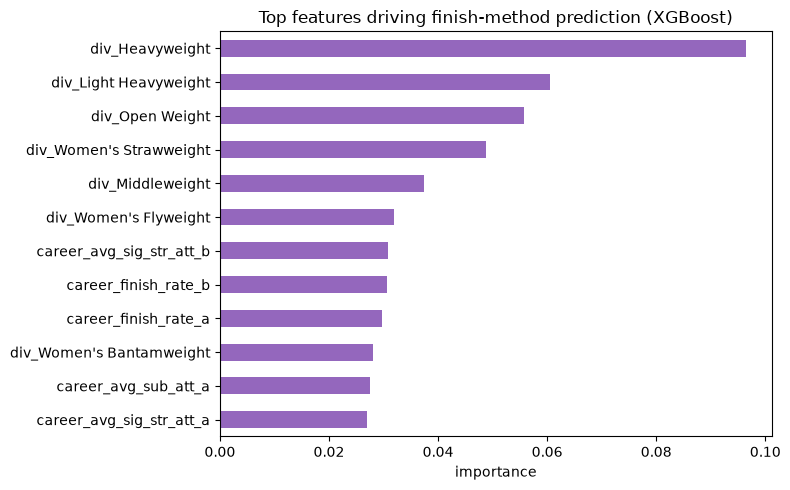

div_Heavyweight             0.096
div_Light Heavyweight       0.060
div_Open Weight             0.056
div_Women's Strawweight     0.049
div_Middleweight            0.037
div_Women's Flyweight       0.032
career_avg_sig_str_att_b    0.031
career_finish_rate_b        0.031


In [21]:
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
imp.head(12).iloc[::-1].plot.barh(ax=ax, color='tab:purple')
ax.set_title('Top features driving finish-method prediction (XGBoost)')
ax.set_xlabel('importance')
plt.tight_layout(); plt.show()
print(imp.head(8).round(3).to_string())

## 6. Persist model + combined `predict_fight` helper

Save the finish model, then wire everything into one function returning win probability, both
corners' odds, and the finish-method distribution - the full output the serving app will use.

In [22]:
finish_model = xgb if best == 'XGBoost' else lr
joblib.dump({
    'model': finish_model,
    'features': list(X.columns),
    'num_features': NUM_FEATURES,
    'classes': CLASSES,
    'is_xgb': best == 'XGBoost',
    'age_medians': age_medians.to_dict(),
}, MODELS_DIR / 'finish_method.joblib')
print('saved finish-method model ->', MODELS_DIR / 'finish_method.joblib')

saved finish-method model -> ../models/finish_method.joblib


In [23]:
def predict_fight(row):
    """row: a Series from ff (one fight). Returns win odds + finish-method distribution."""
    xw = row[WIN_FEATURES].fillna(0).to_frame().T
    p_a = float(win_model.predict_proba(xw)[0, 1])
    fav_p = max(p_a, 1 - p_a)

    xf = pd.DataFrame(0.0, index=[0], columns=X.columns)
    for col in NUM_FEATURES:
        if col in row.index and pd.notna(row[col]):
            xf.at[0, col] = row[col]
    divcol = f"div_{row['division']}"
    if divcol in xf.columns:
        xf.at[0, divcol] = 1
    proba = finish_model.predict_proba(xf)[0]
    labels = CLASSES if best == 'XGBoost' else list(finish_model.classes_)
    fm = dict(zip(labels, proba))

    return {
        'p_fighter_a': round(p_a, 3),
        'favorite': 'A' if p_a >= 0.5 else 'B',
        'fav_win_prob': round(fav_p, 3),
        'fav_american_odds': int(american_odds(fav_p)),
        'fav_decimal_odds': round(float(decimal_odds(fav_p)), 2),
        'finish_method': {k: round(float(v), 3)
                          for k, v in sorted(fm.items(), key=lambda x: -x[1])},
    }

for _, r in ff[~is_train].tail(3).iterrows():
    print(f"{r['division']:<20} {r['date'].date()}")
    print('  ', predict_fight(r))
    print()

Bantamweight         2026-06-27
   {'p_fighter_a': 0.69, 'favorite': 'A', 'fav_win_prob': 0.69, 'fav_american_odds': -223, 'fav_decimal_odds': 1.45, 'finish_method': {'Decision': 0.458, 'KO/TKO': 0.293, 'Submission': 0.25}}

Middleweight         2026-06-27
   {'p_fighter_a': 0.544, 'favorite': 'A', 'fav_win_prob': 0.544, 'fav_american_odds': -120, 'fav_decimal_odds': 1.84, 'finish_method': {'KO/TKO': 0.432, 'Decision': 0.417, 'Submission': 0.151}}

Welterweight         2026-06-27
   {'p_fighter_a': 0.498, 'favorite': 'B', 'fav_win_prob': 0.502, 'fav_american_odds': -101, 'fav_decimal_odds': 1.99, 'finish_method': {'Decision': 0.431, 'KO/TKO': 0.348, 'Submission': 0.221}}

